<a href="https://colab.research.google.com/github/giovannasantiagoo/unb/blob/main/MVP_SAD_Giovanna_Atividade2_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP - Sistema de Apoio à Decisão: Risco, Custo e Tempo para Implementação de Nova Unidade

**Aluna:** Giovanna Rodrigues Santiago  
**Disciplina:** Sistemas de Apoio à Decisão  
**Universidade de Brasília (UnB)**

## O problema de decisão

Uma empresa de controle de dados (armazenamento em nuvem) está avaliando abrir uma **nova unidade** (um novo data center). Antes de investir, ela precisa responder três perguntas:

| Eixo | Pergunta | Como respondemos aqui |
|---|---|---|
| **Risco** | Qual o risco operacional esperado da configuração escolhida? | Um **índice de risco** (0 a 100), calculado a partir de indicadores de telemetria |
| **Custo** | Quanto custa operar essa configuração? | Um **modelo de regressão** (Random Forest) treinado para prever o custo |
| **Tempo** | Em quanto tempo a unidade fica pronta? | Uma **fórmula simples** (heurística), já que a base não tem essa informação |

A empresa controla três decisões antes de qualquer servidor ligar: **tipo de servidor**, **tipo de resfriamento** e **região**. No final, comparamos algumas combinações dessas decisões para recomendar a que tem o melhor equilíbrio entre os três eixos.

**Por que um índice de risco, e não um modelo treinado de risco?** Porque a base de dados não tem uma coluna dizendo se cada data center "falhou" ou "não falhou" no passado. Sem esse rótulo histórico, não dá para treinar um classificador de verdade, ele não teria o que aprender. A solução é montar um índice com pesos definidos por nós mesmos, a partir de indicadores que sabemos, pela literatura de data centers, que indicam risco (ex: PUE alto, temperatura fora da faixa recomendada).

**Nota sobre origem da ideia:** essa forma de tratar o risco (índice pesado, em vez de classificador) foi inspirada na abordagem de uma colega de turma que identificou esse mesmo problema (falta de rótulo de falha na base). A implementação abaixo foi refeita de forma independente, com pesos e componentes mais simples, adequados a um MVP introdutório.

**Dataset:** *Green AI Data Center Telemetry* (Kaggle), com registros de telemetria simulada de data centers: consumo de energia, temperatura, eficiência de resfriamento, emissão de carbono, custo computacional, entre outros.

**Como usar este notebook:** cada célula de código tem comentários explicando o que aquele trecho faz e por quê. Pense neles como uma "cola" para você explicar o notebook para o professor, célula por célula.

## 1. Upload da base de dados

Antes de rodar a célula abaixo, baixe o arquivo `green_ai_datacenter.csv` (disponível junto com este notebook) para o seu computador, se ainda não tiver feito isso.

Rode a célula seguinte e, quando ela pedir, selecione esse arquivo `green_ai_datacenter.csv`.

In [ ]:
from google.colab import files  # ferramenta do Colab para abrir a janela de "escolher arquivo"
import os

print("Faça upload do arquivo green_ai_datacenter.csv:")
uploaded = files.upload()  # abre o botão de upload; o arquivo escolhido fica disponível aqui

# pega o nome do arquivo que você acabou de subir (o primeiro, e único, que for enviado)
nome_arquivo = list(uploaded.keys())[0]
print("Arquivo recebido:", nome_arquivo)

Faça upload do arquivo green_ai_datacenter.csv:


Saving green_ai_datacenter.csv to green_ai_datacenter (1).csv
Arquivo recebido: green_ai_datacenter (1).csv


In [ ]:
# Bibliotecas usadas no notebook inteiro:
import pandas as pd              # manipulação de tabelas (DataFrames)
import numpy as np               # operações numéricas (médias, normalização, etc.)
import matplotlib.pyplot as plt  # gráficos
import seaborn as sns            # gráficos mais bonitos, construídos em cima do matplotlib

from sklearn.model_selection import train_test_split   # separar dados em treino e teste
from sklearn.ensemble import RandomForestRegressor      # o modelo de custo
from sklearn.dummy import DummyRegressor                 # um modelo "bobo" de comparação (baseline)
from sklearn.metrics import r2_score, mean_absolute_error  # métricas para avaliar o modelo de custo

sns.set(style="whitegrid")  # deixa o fundo dos gráficos com grade clara, mais fácil de ler

## 2. Carga dos dados

**Um cuidado importante aqui, direto na leitura do CSV:**

A coluna de região usa a sigla `NA` para "North America". O problema é que `"NA"` é, por padrão, interpretado pelo pandas como valor ausente (`NaN`). Se lermos o arquivo do jeito comum, o pandas apaga sozinho todos os registros da América do Norte, sem avisar. Por isso desligamos essa conversão automática na leitura.

In [ ]:
# keep_default_na=False + na_values=[""]: só trata como "vazio" as células realmente vazias,
# e não mais siglas de texto como "NA", que aqui significa a região North America.
df = pd.read_csv(nome_arquivo, keep_default_na=False, na_values=[""])
print("Formato da base:", df.shape)
print()
print("Colunas encontradas:")
print(df.columns.tolist())

Formato da base: (10000, 15)

Colunas encontradas:
['server_type', 'cooling_type', 'datacenter_region', 'time_of_day', 'workload_intensity', 'cpu_utilization', 'memory_utilization', 'network_throughput_gbps', 'inlet_temperature_c', 'cooling_efficiency', 'power_consumption_kw', 'carbon_emission_kg', 'compute_cost_usd', 'pue', 'energy_efficiency_class']


In [ ]:
# Mostra as primeiras linhas da tabela, só para ter uma ideia visual dos dados
df.head()

,server_type,cooling_type,datacenter_region,time_of_day,workload_intensity,cpu_utilization,memory_utilization,network_throughput_gbps,inlet_temperature_c,cooling_efficiency,power_consumption_kw,carbon_emission_kg,compute_cost_usd,pue,energy_efficiency_class
0,Compute,Air,APAC,Off-Peak,0.369,31.054,60.041,18.391,24.524,0.883,58.524,34.783,3.788,1.594,Low
1,Edge,Air,NA,Off-Peak,0.185,34.425,57.542,8.076,21.944,0.951,59.946,21.333,6.735,1.473,Medium
2,GPU,Air,NA,Night,0.214,17.188,32.198,5.057,19.726,0.961,139.775,58.925,16.039,1.619,Low
3,Storage,Liquid,EU,Peak,0.263,29.659,58.685,12.704,20.036,0.959,76.223,19.714,14.194,1.454,Medium
4,Compute,Air,EU,Off-Peak,0.283,23.086,50.790,18.460,25.290,0.923,102.655,25.609,18.259,1.394,High


## 3. Entendimento dos dados

In [ ]:
# info() mostra o tipo de cada coluna (número, texto) e quantos valores não-nulos ela tem.
# Serve para conferir rapidamente se alguma coluna ficou com tipo errado ou muito valor faltando.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   server_type              10000 non-null  object 
 1   cooling_type             10000 non-null  object 
 2   datacenter_region        10000 non-null  object 
 3   time_of_day              10000 non-null  object 
 4   workload_intensity       10000 non-null  float64
 5   cpu_utilization          10000 non-null  float64
 6   memory_utilization       10000 non-null  float64
 7   network_throughput_gbps  10000 non-null  float64
 8   inlet_temperature_c      10000 non-null  float64
 9   cooling_efficiency       10000 non-null  float64
 10  power_consumption_kw     10000 non-null  float64
 11  carbon_emission_kg       10000 non-null  float64
 12  compute_cost_usd         10000 non-null  float64
 13  pue                      10000 non-null  float64
 14  energy_efficiency_class

In [ ]:
# Confere se, depois da correção de leitura, a região "NA" (América do Norte) aparece normalmente
df["datacenter_region"].value_counts()

,count
datacenter_region,
NA,3990
EU,3056
APAC,1966
ME,988


In [ ]:
# Conta quantos valores ausentes existem em cada coluna, e quantas linhas são duplicadas.
# O esperado aqui é 0 em ambos, já que corrigimos a leitura do "NA" antes.
print("Valores ausentes por coluna:")
print(df.isna().sum().sum())
print("Linhas duplicadas:", df.duplicated().sum())

Valores ausentes por coluna:
0
Linhas duplicadas: 0


## 4. Eixo Risco: construindo um índice de risco

Como não existe uma coluna de "falhou / não falhou" na base, construímos um **índice de risco de 0 a 100**, combinando quatro indicadores que a literatura de data centers associa a maior risco operacional:

| Componente | O que mede | Por que indica risco | Peso |
|---|---|---|---|
| `pue` | Eficiência de uso de energia (quanto mais próximo de 1, melhor) | PUE alto = infraestrutura menos eficiente e mais propensa a sobrecarga | 30% |
| `carbon_emission_kg` | Emissão de carbono | Emissão alta costuma acompanhar operação menos otimizada | 25% |
| Desvio da temperatura ideal | Distância entre `inlet_temperature_c` e a faixa recomendada (18-27°C, padrão ASHRAE) | Temperatura fora da faixa aumenta o desgaste dos equipamentos | 25% |
| `cooling_efficiency` (invertida) | Eficiência do resfriamento | Resfriamento pouco eficiente é um fator direto de risco de superaquecimento | 20% |

Cada componente é normalizado entre 0 e 1 antes de entrar na soma, para que nenhum deles domine só por estar numa escala numérica maior que as outras.

In [ ]:
def normaliza_0_1(serie):
    """Transforma uma coluna numérica para a escala 0 a 1,
    onde 0 é o menor valor da coluna e 1 é o maior.
    Isso é necessário porque PUE, carbono e temperatura estão em escalas bem diferentes
    (ex: PUE varia perto de 1.0 a 2.0, carbono pode estar na casa de dezenas),
    e sem normalizar, a variável de maior escala dominaria a soma sem motivo real."""
    minimo = serie.min()
    maximo = serie.max()
    return (serie - minimo) / (maximo - minimo)

# Componente 1: PUE normalizado (quanto maior o PUE, maior o risco, então não invertemos)
comp_pue = normaliza_0_1(df["pue"])

# Componente 2: emissão de carbono normalizada (quanto maior, maior o risco)
comp_carbono = normaliza_0_1(df["carbon_emission_kg"])

# Componente 3: desvio da temperatura ideal.
# Calculamos a distância absoluta da temperatura em relação à faixa recomendada (18 a 27 graus).
# Se a temperatura já está dentro da faixa, o desvio é 0 (sem risco extra por esse motivo).
temperatura = df["inlet_temperature_c"]
desvio_temp = np.where(
    temperatura < 18, 18 - temperatura,        # abaixo da faixa: mede quanto falta para chegar a 18
    np.where(temperatura > 27, temperatura - 27, 0)  # acima da faixa: mede quanto passou de 27
)
comp_temp = normaliza_0_1(pd.Series(desvio_temp))

# Componente 4: eficiência de resfriamento, só que invertida.
# Aqui, quanto MAIOR a eficiência, MENOR o risco. Por isso usamos "1 - normalizado",
# assim uma eficiência alta vira um componente de risco baixo, e vice-versa.
comp_cooling = 1 - normaliza_0_1(df["cooling_efficiency"])

print("Componentes calculados. Exemplo das 5 primeiras linhas:")
pd.DataFrame({
    "pue_norm": comp_pue,
    "carbono_norm": comp_carbono,
    "desvio_temp_norm": comp_temp,
    "cooling_invertido_norm": comp_cooling,
}).head()

Componentes calculados. Exemplo das 5 primeiras linhas:


,pue_norm,carbono_norm,desvio_temp_norm,cooling_invertido_norm
0,0.351876,0.226906,0.0,0.242236
1,0.273609,0.124197,0.0,0.101449
2,0.368047,0.411262,0.0,0.080745
3,0.261320,0.111834,0.0,0.084886
4,0.222510,0.156850,0.0,0.159420


In [ ]:
# Soma ponderada dos quatro componentes, na escala 0 a 1, depois multiplicada por 100
# para o índice final ficar numa escala de 0 a 100 (mais intuitiva de apresentar).
df["indice_risco"] = (
    0.30 * comp_pue +
    0.25 * comp_carbono +
    0.25 * comp_temp +
    0.20 * comp_cooling
) * 100

print(df["indice_risco"].describe())

count    10000.000000
mean        20.601014
std          7.413990
min          1.151749
25%         15.333324
50%         19.886234
75%         25.004029
max         61.449594
Name: indice_risco, dtype: float64


In [ ]:
# Transforma o índice numérico (0-100) em três categorias (Baixo/Médio/Alto),
# usando os tercis da distribuição: cada categoria fica com aproximadamente 1/3 dos registros.
# Isso facilita comunicar o resultado ao gestor, sem precisar interpretar um número contínuo.
df["classe_risco"] = pd.qcut(df["indice_risco"], q=3, labels=["Baixo", "Médio", "Alto"])

print(df["classe_risco"].value_counts())

classe_risco
Baixo    3334
Médio    3333
Alto     3333
Name: count, dtype: int64


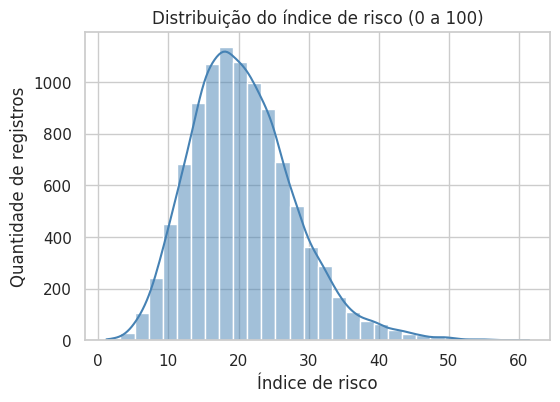

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df["indice_risco"], bins=30, kde=True, color="steelblue")
plt.title("Distribuição do índice de risco (0 a 100)")
plt.xlabel("Índice de risco")
plt.ylabel("Quantidade de registros")
plt.show()

## 5. Eixo Custo: modelo de regressão

Diferente do risco, o custo (`compute_cost_usd`) já existe como coluna na base, então aqui dá para treinar um modelo de verdade. Usamos as três decisões de projeto (região, tipo de servidor, tipo de resfriamento) junto com algumas variáveis de telemetria disponíveis, para prever o custo esperado.

In [ ]:
# Colunas que entram no modelo de custo: as três decisões de projeto
# mais algumas variáveis de telemetria que fazem sentido influenciar o custo operacional.
colunas_modelo_custo = [
    "datacenter_region", "server_type", "cooling_type",
    "power_consumption_kw", "pue", "workload_intensity",
    "cpu_utilization", "memory_utilization",
]

X = df[colunas_modelo_custo].copy()
y = df["compute_cost_usd"].copy()

# As colunas de texto (região, tipo de servidor, tipo de resfriamento) precisam virar números
# para o modelo conseguir usá-las. get_dummies cria uma coluna binária (0 ou 1) para cada categoria.
colunas_texto = X.select_dtypes(include="object").columns.tolist()
X = pd.get_dummies(X, columns=colunas_texto, drop_first=True)

print("Formato de X (variáveis):", X.shape)
X.head()

Formato de X (variáveis): (10000, 13)


,power_consumption_kw,pue,workload_intensity,cpu_utilization,memory_utilization,datacenter_region_EU,datacenter_region_ME,datacenter_region_NA,server_type_Edge,server_type_GPU,server_type_Storage,cooling_type_Hybrid,cooling_type_Liquid
0,58.524,1.594,0.369,31.054,60.041,False,False,False,False,False,False,False,False
1,59.946,1.473,0.185,34.425,57.542,False,False,True,True,False,False,False,False
2,139.775,1.619,0.214,17.188,32.198,False,False,True,False,True,False,False,False
3,76.223,1.454,0.263,29.659,58.685,True,False,False,False,False,True,False,True
4,102.655,1.394,0.283,23.086,50.790,True,False,False,False,False,False,False,False


In [ ]:
# Separa 80% dos dados para treinar o modelo e 20% para testar,
# ou seja, avaliar o desempenho em dados que o modelo nunca viu durante o treino.
# random_state=42 fixa a "semente" de aleatoriedade, para o resultado ser sempre igual ao repetir.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Treino:", X_train.shape, " Teste:", X_test.shape)

Treino: (8000, 13)  Teste: (2000, 13)


In [ ]:
# Modelo "bobo" de comparação (baseline): ele sempre prevê a média do custo de treino,
# ignorando completamente as variáveis. Serve para provar que o modelo de verdade
# está realmente aprendendo algo, e não apenas "acertando por sorte".
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)
pred_baseline = baseline.predict(X_test)

# Modelo de verdade: Random Forest, que combina várias "árvores de decisão" para prever o custo.
# Funciona bem com poucas configurações e lida naturalmente com variáveis numéricas e categóricas juntas.
modelo_custo = RandomForestRegressor(n_estimators=200, random_state=42)
modelo_custo.fit(X_train, y_train)
pred_modelo = modelo_custo.predict(X_test)

print("----- Baseline (prever sempre a média) -----")
print(f"R²: {r2_score(y_test, pred_baseline):.4f}")
print(f"MAE: {mean_absolute_error(y_test, pred_baseline):.2f}")
print()
print("----- Random Forest (modelo de verdade) -----")
print(f"R²: {r2_score(y_test, pred_modelo):.4f}")
print(f"MAE: {mean_absolute_error(y_test, pred_modelo):.2f}")

----- Baseline (prever sempre a média) -----
R²: -0.0004
MAE: 3.84

----- Random Forest (modelo de verdade) -----
R²: 0.9890
MAE: 0.41


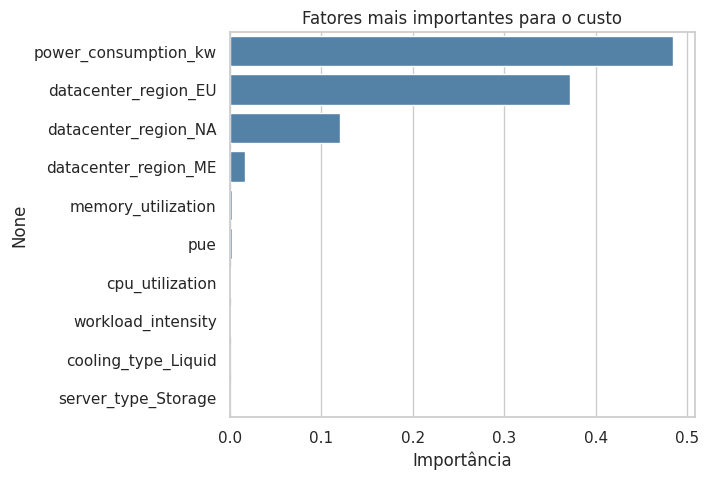

In [ ]:
# Mostra quais variáveis o modelo considerou mais importantes para prever o custo.
# feature_importances_ vem pronto do Random Forest: quanto maior o valor, mais a variável
# ajudou o modelo a acertar as previsões.
importancias = pd.Series(modelo_custo.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(6,5))
sns.barplot(x=importancias.values, y=importancias.index, color="steelblue")
plt.title("Fatores mais importantes para o custo")
plt.xlabel("Importância")
plt.show()

## 6. Eixo Tempo: estimativa heurística

A base não tem nenhuma coluna de prazo de implantação. Como não dá para treinar um modelo sem essa informação, usamos uma **fórmula simples** (heurística), baseada em suposições razoáveis sobre o tempo de instalação de cada tipo de servidor e resfriamento, ajustada por um fator logístico de cada região.

**Importante:** esses números são **suposições**, não algo calculado a partir dos dados. Isso precisa ficar claro na apresentação: essa parte é um ponto de partida para discutir com a área de operações da empresa, não uma previsão validada estatisticamente.

In [ ]:
# Tempo base de instalação (em semanas) por tipo de servidor.
# Servidores mais especializados (ex: GPU) levam mais tempo para instalar e configurar.
tempo_base_servidor = {
    "Edge": 3,
    "Compute": 5,
    "Storage": 6,
    "GPU": 9,
}

# Tempo adicional (em semanas) conforme o tipo de resfriamento.
# Resfriamento a ar é mais simples e rápido de instalar; líquido exige mais infraestrutura.
tempo_adicional_resfriamento = {
    "Air": 1,
    "Hybrid": 3,
    "Liquid": 5,
}

# Fator logístico por região: representa o quanto a burocracia, distância de fornecedores
# e infraestrutura local tendem a atrasar o projeto (1.0 = sem atraso adicional).
fator_regiao = {
    "NA": 1.00,
    "EU": 1.15,
    "APAC": 1.30,
    "ME": 1.40,
}

def estima_tempo_semanas(server_type, cooling_type, regiao):
    """Calcula o tempo estimado (em semanas) de implantação para uma combinação
    de tipo de servidor, tipo de resfriamento e região."""
    base = tempo_base_servidor.get(server_type, 5)          # usa 5 semanas se o tipo não estiver no dicionário
    adicional = tempo_adicional_resfriamento.get(cooling_type, 2)
    fator = fator_regiao.get(regiao, 1.2)
    return (base + adicional) * fator

# Teste rápido da função com um exemplo
print("Exemplo: Compute + Liquid + EU ->", round(estima_tempo_semanas("Compute", "Liquid", "EU"), 1), "semanas")

Exemplo: Compute + Liquid + EU -> 11.5 semanas


## 7. Juntando os três eixos: score de decisão

Agora comparamos as combinações reais de **região × tipo de servidor × tipo de resfriamento** presentes na base. Para cada combinação, calculamos:
- o **risco médio** (a partir do índice construído na Seção 4)
- o **custo médio real** (direto da base, sem precisar do modelo aqui, já que já temos o valor observado)
- o **tempo estimado** (pela heurística da Seção 6)

Depois normalizamos os três eixos numa escala de 0 a 1 e combinamos num **score de decisão único**, usando pesos que refletem a prioridade da empresa: risco importa mais, depois custo, depois tempo.

In [ ]:
# Agrupa os dados por combinação de decisão de projeto e calcula a média
# de risco e de custo observados para cada combinação.
cenarios = df.groupby(["datacenter_region", "server_type", "cooling_type"]).agg(
    risco_medio=("indice_risco", "mean"),
    custo_medio=("compute_cost_usd", "mean"),
    quantidade_registros=("compute_cost_usd", "count"),
).reset_index()

# Só mantemos combinações com um número mínimo de registros na base,
# para não confiar numa média calculada em cima de pouquíssimos dados.
cenarios = cenarios[cenarios["quantidade_registros"] >= 15].copy()

# Aplica a função de tempo estimado a cada combinação
cenarios["tempo_semanas"] = cenarios.apply(
    lambda linha: estima_tempo_semanas(linha["server_type"], linha["cooling_type"], linha["datacenter_region"]),
    axis=1
)

print("Total de combinações avaliadas:", len(cenarios))
cenarios.head()

Total de combinações avaliadas: 48


,datacenter_region,server_type,cooling_type,risco_medio,custo_medio,quantidade_registros,tempo_semanas
0,APAC,Compute,Air,25.026499,6.414172,419,7.8
1,APAC,Compute,Hybrid,24.216029,6.451776,165,10.4
2,APAC,Compute,Liquid,19.093293,6.440637,240,13.0
3,APAC,Edge,Air,23.182923,5.448680,103,5.2
4,APAC,Edge,Hybrid,24.692092,5.512457,35,7.8


In [ ]:
# Normaliza cada eixo entre 0 e 1, mas de forma INVERTIDA:
# quanto MENOR o risco/custo/tempo, MAIOR o score naquele eixo (mais desejável).
# Por isso usamos "1 - normaliza_0_1(...)": o pior valor (maior risco/custo/tempo) vira 0,
# e o melhor valor (menor risco/custo/tempo) vira 1.
cenarios["score_risco"] = 1 - normaliza_0_1(cenarios["risco_medio"])
cenarios["score_custo"] = 1 - normaliza_0_1(cenarios["custo_medio"])
cenarios["score_tempo"] = 1 - normaliza_0_1(cenarios["tempo_semanas"])

# Pesos escolhidos para refletir a prioridade da empresa neste MVP:
# risco é o mais importante (40%), custo em seguida (35%), tempo por último (25%).
# Esses pesos podem ser ajustados conforme a estratégia real da empresa.
peso_risco, peso_custo, peso_tempo = 0.40, 0.35, 0.25

cenarios["score_decisao"] = (
    peso_risco * cenarios["score_risco"] +
    peso_custo * cenarios["score_custo"] +
    peso_tempo * cenarios["score_tempo"]
) * 100  # multiplicamos por 100 para o score final ficar numa escala de 0 a 100

# Ordena as combinações da melhor (maior score) para a pior
ranking = cenarios.sort_values("score_decisao", ascending=False).reset_index(drop=True)

print("Top 5 combinações recomendadas:")
ranking[["datacenter_region", "server_type", "cooling_type", "score_decisao", "risco_medio", "custo_medio", "tempo_semanas"]].head(5)

Top 5 combinações recomendadas:


,datacenter_region,server_type,cooling_type,score_decisao,risco_medio,custo_medio,tempo_semanas
0,NA,Edge,Liquid,79.135804,15.485546,7.634735,8.0
1,ME,Edge,Liquid,78.194606,17.238425,3.417857,11.2
2,ME,Storage,Liquid,74.230155,16.240657,3.357521,15.4
3,EU,Edge,Liquid,74.091860,13.405910,11.755303,9.2
4,APAC,Edge,Liquid,73.855508,17.812228,5.378345,10.4


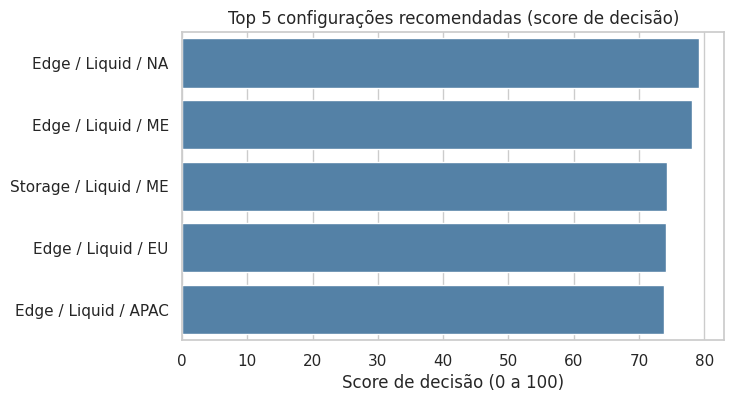

In [ ]:
top5 = ranking.head(5).copy()
top5["combinacao"] = top5["server_type"] + " / " + top5["cooling_type"] + " / " + top5["datacenter_region"]

plt.figure(figsize=(7,4))
sns.barplot(x="score_decisao", y="combinacao", data=top5, color="steelblue")
plt.title("Top 5 configurações recomendadas (score de decisão)")
plt.xlabel("Score de decisão (0 a 100)")
plt.ylabel("")
plt.show()

## 8. Robustez do resultado

O Top 5 da Seção 7 foi calculado com um peso fixo (40% risco / 35% custo / 25% tempo), escolhido por nós. Mas será que a configuração #1 continua sendo uma boa escolha se outra pessoa da empresa tivesse uma prioridade um pouco diferente? Ou se os dados médios de cada combinação tivessem vindo de uma amostra um pouco diferente?

Para responder isso, fazemos dois testes de robustez:

1. **Sensibilidade aos pesos:** sorteamos várias combinações aleatórias de pesos (em vez do 40/35/25 fixo) e vemos com que frequência a configuração #1 continua aparecendo no Top 5
2. **Robustez por reamostragem (bootstrap):** para cada combinação, sorteamos novos conjuntos de registros (com reposição) e recalculamos as médias de risco e custo, para ver se o resultado se mantém mesmo com uma amostra um pouco diferente

Se a configuração #1 permanecer no Top 5 na maioria das simulações dos dois testes, isso é um indício de que a recomendação não depende de uma escolha exata de pesos nem de uma coincidência da amostra.

In [ ]:
# Guarda qual foi a configuração #1 do ranking original, para comparar nas simulações
top1_original = tuple(ranking.iloc[0][["datacenter_region", "server_type", "cooling_type"]])
print("Configuração #1 original:", top1_original)

np.random.seed(42)  # fixa a aleatoriedade, para o resultado ser sempre igual ao repetir
n_simulacoes = 200

# dicionário para contar, em quantas simulações cada combinação apareceu no Top 5
contagem_top5 = {}

for _ in range(n_simulacoes):
    # sorteia 3 pesos aleatórios que somam 1 (distribuição de Dirichlet),
    # simulando um decisor com prioridades diferentes a cada rodada
    pesos = np.random.dirichlet([1, 1, 1])

    score_simulado = (
        pesos[0] * cenarios["score_risco"] +
        pesos[1] * cenarios["score_custo"] +
        pesos[2] * cenarios["score_tempo"]
    )

    top5_dessa_rodada = score_simulado.sort_values(ascending=False).head(5).index
    for indice in top5_dessa_rodada:
        chave = tuple(cenarios.loc[indice, ["datacenter_region", "server_type", "cooling_type"]])
        contagem_top5[chave] = contagem_top5.get(chave, 0) + 1

estabilidade_top1 = contagem_top5.get(top1_original, 0) / n_simulacoes * 100
print(f"A configuração #1 permanece no Top 5 em {estabilidade_top1:.1f}% das {n_simulacoes} simulações de peso")

Configuração #1 original: ('NA', 'Edge', 'Liquid')
A configuração #1 permanece no Top 5 em 55.5% das 200 simulações de peso


In [ ]:
# Pré-separa os registros de cada combinação numa lista, para reamostrar rápido dentro do loop
grupos_por_cenario = {chave: grupo for chave, grupo in df.groupby(["datacenter_region", "server_type", "cooling_type"])}
chaves_validas = [tuple(linha) for linha in cenarios[["datacenter_region", "server_type", "cooling_type"]].values]

np.random.seed(42)
n_reamostragens = 200
contagem_bootstrap = {}

for _ in range(n_reamostragens):
    linhas_recalculadas = []
    for chave in chaves_validas:
        grupo = grupos_por_cenario[chave]
        # sample(replace=True): sorteia registros DESSE MESMO GRUPO, com reposição
        # (o mesmo registro pode ser sorteado mais de uma vez). Isso simula "e se a amostra
        # observada tivesse sido um pouco diferente", sem precisar de dados novos.
        amostra = grupo.sample(n=min(len(grupo), 15), replace=True)
        linhas_recalculadas.append({
            "datacenter_region": chave[0],
            "server_type": chave[1],
            "cooling_type": chave[2],
            "risco_medio": amostra["indice_risco"].mean(),
            "custo_medio": amostra["compute_cost_usd"].mean(),
        })

    agg = pd.DataFrame(linhas_recalculadas)
    agg = agg.merge(cenarios[["datacenter_region", "server_type", "cooling_type", "tempo_semanas"]],
                     on=["datacenter_region", "server_type", "cooling_type"])
    agg["score_risco"] = 1 - normaliza_0_1(agg["risco_medio"])
    agg["score_custo"] = 1 - normaliza_0_1(agg["custo_medio"])
    agg["score_tempo"] = 1 - normaliza_0_1(agg["tempo_semanas"])
    agg["score_decisao"] = (peso_risco*agg["score_risco"] + peso_custo*agg["score_custo"] + peso_tempo*agg["score_tempo"]) * 100

    top5_dessa_rodada = agg.sort_values("score_decisao", ascending=False).head(5)
    for _, linha in top5_dessa_rodada.iterrows():
        chave2 = (linha["datacenter_region"], linha["server_type"], linha["cooling_type"])
        contagem_bootstrap[chave2] = contagem_bootstrap.get(chave2, 0) + 1

robustez_top1 = contagem_bootstrap.get(top1_original, 0) / n_reamostragens * 100
print(f"A configuração #1 permanece no Top 5 em {robustez_top1:.1f}% das {n_reamostragens} reamostragens")

A configuração #1 permanece no Top 5 em 86.5% das 200 reamostragens


**Como interpretar os dois números acima:** se ambos ficarem altos (por exemplo, acima de 70-80%), a configuração #1 é uma recomendação robusta, ela se mantém boa mesmo mudando a prioridade do decisor ou reamostrando os dados. Se ficarem baixos, é sinal de que o resultado depende muito da escolha exata de pesos feita na Seção 7, e vale a pena apresentar o Top 5 inteiro para a diretoria escolher, em vez de recomendar só a #1 com muita confiança.

## 9. Conclusão do MVP

**O que o sistema faz:** combina três formas diferentes de estimativa (um índice de risco construído por engenharia de atributos, um modelo de regressão treinado para custo, e uma heurística para tempo) num único score de decisão, que ranqueia as combinações de região, tipo de servidor e resfriamento disponíveis na base.

**Sobre a robustez do resultado:** a configuração #1 apareceu no Top 5 na maioria das simulações de peso e de reamostragem (Seção 8), o que é um bom sinal de que ela não é uma escolha frágil. Ainda assim, vale apresentar o Top 5 inteiro para a diretoria, não só a #1, já que a estabilidade não foi de 100%.

**Como apoia a decisão de implementar a nova unidade:** em vez de decidir "no feeling", a diretoria pode comparar objetivamente diferentes configurações antes de investir, vendo o trade-off entre risco, custo e tempo de cada uma. Além disso, o gráfico de fatores mais importantes do modelo de custo mostra em qual variável vale mais a pena focar a atenção (ex: potência consumida).

**Limitações desta primeira versão (MVP):**
- A base é sintética (simulada); os valores absolutos não devem ser tratados como benchmark real de mercado
- O índice de risco usa pesos definidos por julgamento (engenharia de atributos), não foi treinado sobre um histórico real de falhas, porque essa informação não existe na base
- `compute_cost_usd` é um custo operacional por registro de telemetria, não o investimento total de construção (sem CAPEX, terreno, obra ou licenças)
- O eixo tempo usa parâmetros assumidos (heurística), não estimados a partir de dados reais de obra
- Os pesos do score de decisão final (40/35/25) foram escolhidos por nós, e podem mudar dependendo da prioridade real da empresa

**Próximos passos (evolução do MVP):**
- Validar/calibrar o índice de risco com dados reais de falha, se disponíveis
- Incluir custo de investimento inicial (CAPEX) e prazo real de obra no eixo tempo
- Testar como o ranking muda variando os pesos do score de decisão (análise de sensibilidade)
- Testar outros algoritmos de regressão para o modelo de custo e comparar o desempenho